# Malaria Cell Classification - CNN Assignment
**오늘 한 줄**: 이번 과제는 기존 CNN 베이스라인 흐름을 말라리아 이진분류에 맞게 다시 설계하는 것이다.

흐름: 데이터 확인 -> EDA -> v1 베이스라인 -> 내가 설계한 모델 -> 결과 비교 -> 제출용 분석 정리

> 데이터: Kaggle `iarunava/cell-images-for-detecting-malaria`
        


## [0] 과제 체크리스트
- [x] 말라리아 데이터셋 이진분류
- [x] v1 베이스라인 모델
- [x] 내가 설계한 모델 1개
- [x] 전체 정확도 / 클래스별 recall / 파라미터 수 비교표
- [x] 학습 곡선 시각화
- [x] 혼동행렬 시각화
- [x] 설계 이유와 결과 해석 작성 공간

참고: 노션 표의 `glacier recall`, `mountain recall`은 이전 과제 문구가 남은 것으로 보이며, 이번 과제에서는 `Parasitized recall`, `Uninfected recall`로 정리한다.
        


In [1]:
import os
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from IPython.display import display
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        torch.manual_seed(seed)
    except Exception as e:
        print(f"torch.manual_seed warning: {e}")

    try:
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
    except Exception as e:
        print(f"cuda seed warning: {e}")

def get_safe_device():
    try:
        if torch.cuda.is_available():
            probe = torch.zeros(1, device="cuda")
            _ = probe.cpu()
            return torch.device("cuda")
    except Exception as e:
        print(f"cuda disabled, fallback to cpu: {e}")
    return torch.device("cpu")

set_seed(SEED)

device = get_safe_device()
print(f"device: {device}")
        


device: cuda


## [1] 데이터 경로 찾기
로컬에서는 `/data` 아래를 우선 찾고, Kaggle Notebook에서는 `/kaggle/input`을 자동 탐색한다.
        


In [2]:
def ensure_local_dataset():
    zip_path = Path("/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/data/cell-images-for-detecting-malaria.zip")
    extract_root = Path("/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/data/malaria-cell-images")
    target_dir = extract_root / "cell_images"

    if target_dir.exists():
        return target_dir

    if zip_path.exists():
        extract_root.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(extract_root)
        return target_dir

    return None


def list_visible_dirs(path):
    return sorted([p.name for p in path.iterdir() if p.is_dir() and not p.name.startswith(".")])


def is_clean_dataset_dir(path):
    if not path or not path.exists():
        return False
    return list_visible_dirs(path) == ["Parasitized", "Uninfected"]


def find_dataset_dir():
    base_candidates = [
        ensure_local_dataset(),
        Path("/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/data/malaria-cell-images"),
        Path("/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/data/malaria-cell-images/cell_images"),
        Path("/mnt/c/Users/sdh08/PycharmProjects/PythonProject1/data/cell_images"),
        Path("/kaggle/input/cell-images-for-detecting-malaria"),
        Path("/kaggle/input/cell-images-for-detecting-malaria/cell_images"),
    ]

    expanded_candidates = []
    for candidate in base_candidates:
        if candidate is None:
            continue
        expanded_candidates.append(candidate / "cell_images")
        expanded_candidates.append(candidate)

    for candidate in expanded_candidates:
        if is_clean_dataset_dir(candidate):
            return candidate

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in kaggle_input.rglob("*"):
            if path.is_dir() and is_clean_dataset_dir(path):
                return path

    raise FileNotFoundError("말라리아 데이터셋 경로를 찾지 못했습니다.")


DATA_DIR = find_dataset_dir()
print(f"DATA_DIR: {DATA_DIR}")
print(list_visible_dirs(DATA_DIR))
        


DATA_DIR: /mnt/c/Users/sdh08/PycharmProjects/PythonProject1/data/malaria-cell-images/cell_images/cell_images
['Parasitized', 'Uninfected']


## [2] EDA - 클래스 분포 + 샘플 이미지
**볼 것**: 감염 세포와 정상 세포가 시각적으로 어떻게 다른가?
        


,class,count
0,Parasitized,13779
1,Uninfected,13779


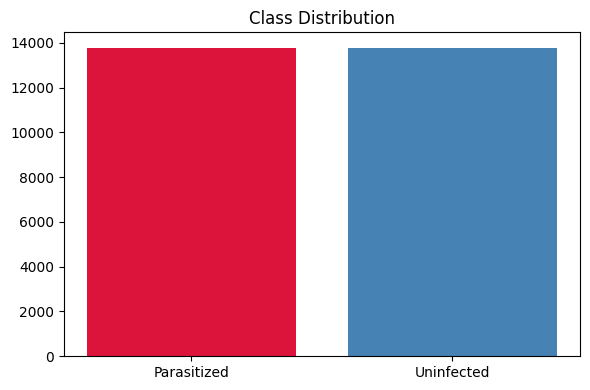

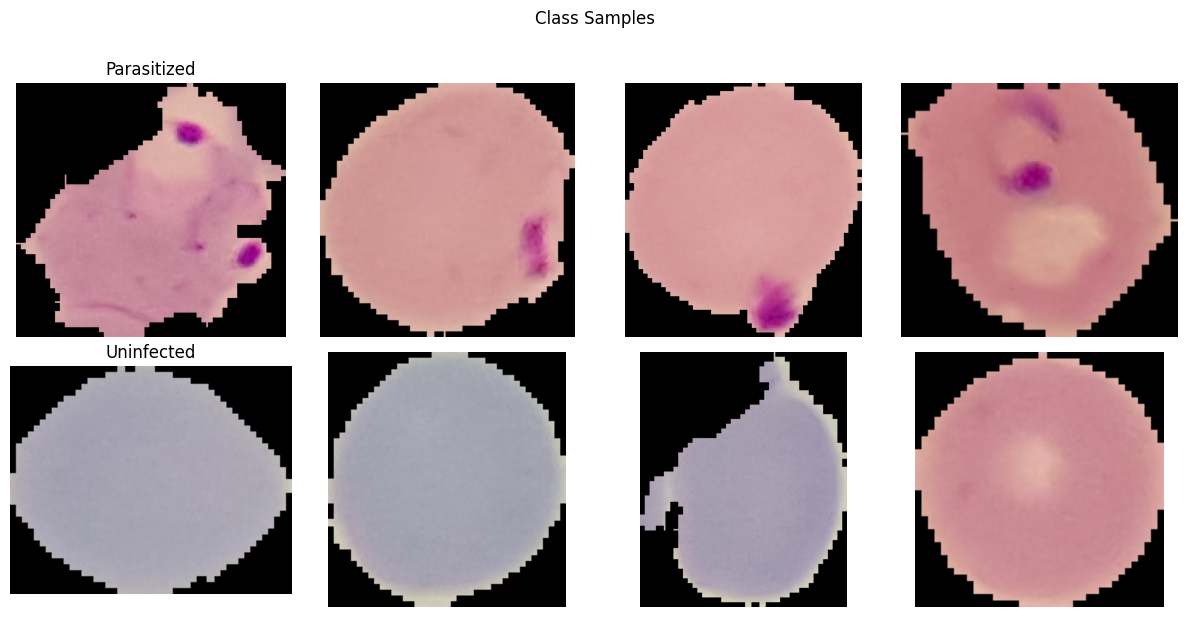

In [3]:
class_names = list_visible_dirs(DATA_DIR)
counts = {cls: len(list((DATA_DIR / cls).glob("*.png"))) for cls in class_names}

display(pd.DataFrame({"class": counts.keys(), "count": counts.values()}))

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["crimson", "steelblue"])
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(class_names), 4, figsize=(12, 6))
for row, cls in enumerate(class_names):
    image_paths = random.sample(list((DATA_DIR / cls).glob("*.png")), 4)
    for col, img_path in enumerate(image_paths):
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls if col == 0 else "")
        axes[row, col].axis("off")
plt.suptitle("Class Samples", y=1.02)
plt.tight_layout()
plt.show()
        


**가설 적기**: 감염 세포는 보라색 기생충 흔적이 보이는 경우가 많고, 정상 세포는 내부 패턴이 더 균일해 보인다.
        


## [3] DataLoader 준비
로컬 데이터셋은 train/val/test가 나뉘어 있지 않으므로 stratified split으로 직접 분할한다.
        


In [4]:
IMG_SIZE = 96
BATCH = 128
NUM_WORKERS = 0

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

full_ds = datasets.ImageFolder(DATA_DIR, transform=transform)
indices = np.arange(len(full_ds))
targets = np.array(full_ds.targets)

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=SEED,
    stratify=targets,
)

temp_targets = targets[temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_targets,
)

train_ds = Subset(full_ds, train_idx)
val_ds = Subset(full_ds, val_idx)
test_ds = Subset(full_ds, test_idx)

pin_memory = device.type == "cuda"
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_dl = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

print(f"train: {len(train_ds)}")
print(f"val:   {len(val_ds)}")
print(f"test:  {len(test_ds)}")
print(f"class_to_idx: {full_ds.class_to_idx}")
print(f"classes: {full_ds.classes}")
print(f"target range: min={targets.min()}, max={targets.max()}, unique={sorted(set(targets.tolist()))}")
assert len(full_ds.classes) == 2, f"expected 2 classes, got {full_ds.classes}"
assert set(targets.tolist()) == {0, 1}, f"unexpected targets: {sorted(set(targets.tolist()))}"
        


train: 19290
val:   4134
test:  4134
class_to_idx: {'Parasitized': 0, 'Uninfected': 1}
classes: ['Parasitized', 'Uninfected']
target range: min=0, max=1, unique=[0, 1]


## [4] Simple CNN 베이스라인
기존 baseline 노트북의 흐름을 그대로 따라가되, 2클래스 문제에 맞게 가장 단순한 3블록 CNN부터 시작한다.
        


In [5]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


baseline_model = SimpleCNN(num_classes=len(full_ds.classes)).to(device)
print(f"baseline params: {count_parameters(baseline_model):,}")
baseline_model
        


baseline params: 4,812,610


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=2, bias=True)
  )
)

## [5] 학습 함수
학습 곡선을 저장해 나중에 제출용 스크린샷으로 사용한다.
        


In [6]:
def train_model(model, train_dl, val_dl, epochs=12, lr=1e-3, patience=3, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    output_dim = model.classifier[-1].out_features
    if output_dim != 2:
        raise ValueError(f"model output dim must be 2, got {output_dim}")

    best_acc = 0.0
    best_state = None
    no_improve = 0
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (imgs, labels) in enumerate(train_dl):
            if labels.min().item() < 0 or labels.max().item() >= output_dim:
                raise ValueError(
                    f"label out of range at train batch {batch_idx}: "
                    f"min={labels.min().item()}, max={labels.max().item()}, output_dim={output_dim}"
                )
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            if logits.shape[1] != output_dim:
                raise ValueError(f"unexpected logits shape: {logits.shape}")
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * imgs.size(0)
            train_correct += (logits.argmax(1) == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_idx, (imgs, labels) in enumerate(val_dl):
                if labels.min().item() < 0 or labels.max().item() >= output_dim:
                    raise ValueError(
                        f"label out of range at val batch {batch_idx}: "
                        f"min={labels.min().item()}, max={labels.max().item()}, output_dim={output_dim}"
                    )
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs)
                loss = criterion(logits, labels)

                val_loss_sum += loss.item() * imgs.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total
        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss {train_loss:.4f} | train_acc {train_acc:.4f} | "
            f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f}"
        )

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history
        


In [7]:
def plot_history(history, title):
    epochs = range(1, len(history["train_acc"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_acc"], marker="o", label="train_acc")
    plt.plot(epochs, history["val_acc"], marker="o", label="val_acc")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
        


## [6] v1 베이스라인 학습
        


Epoch 01 | train_loss 0.3502 | train_acc 0.8360 | val_loss 0.1516 | val_acc 0.9531
Epoch 02 | train_loss 0.1433 | train_acc 0.9534 | val_loss 0.1442 | val_acc 0.9514
Epoch 03 | train_loss 0.1246 | train_acc 0.9581 | val_loss 0.1356 | val_acc 0.9531
Epoch 04 | train_loss 0.1122 | train_acc 0.9608 | val_loss 0.1359 | val_acc 0.9521
Early stopping at epoch 4


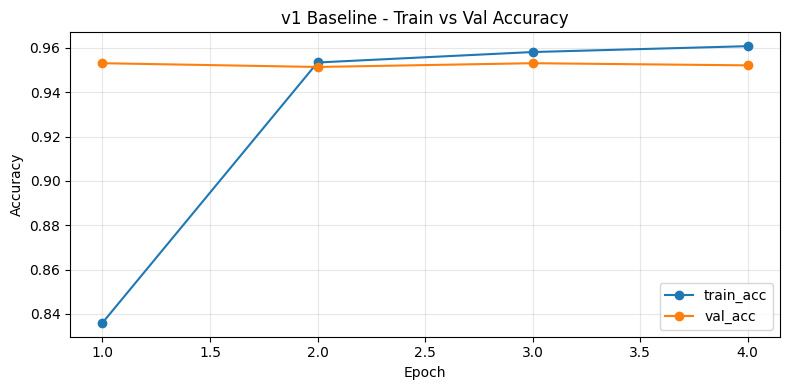

In [8]:
model_v1 = SimpleCNN(num_classes=len(full_ds.classes)).to(device)
model_v1, history_v1 = train_model(model_v1, train_dl, val_dl, epochs=12, lr=1e-3, patience=3)
plot_history(history_v1, "v1 Baseline - Train vs Val Accuracy")
        


## [7] 평가 함수
전체 정확도, 클래스별 recall, 혼동행렬을 한 번에 확인한다.
        


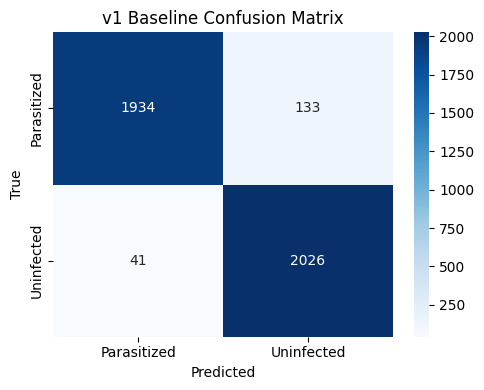

,precision,recall,f1-score,support
Parasitized,0.979241,0.935656,0.956952,2067.00000
Uninfected,0.938397,0.980164,0.958826,2067.00000
accuracy,0.957910,0.957910,0.957910,0.95791
macro avg,0.958819,0.957910,0.957889,4134.00000
weighted avg,0.958819,0.957910,0.957889,4134.00000


In [9]:
idx_to_class = {v: k for k, v in full_ds.class_to_idx.items()}


def evaluate_model(model, data_loader, class_names, title="Confusion Matrix"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = (all_preds == all_labels).mean()
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).T

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    result = {
        "accuracy": acc,
        "parasitized_recall": report["Parasitized"]["recall"],
        "uninfected_recall": report["Uninfected"]["recall"],
        "report_df": report_df,
    }
    return result


result_v1 = evaluate_model(model_v1, test_dl, full_ds.classes, title="v1 Baseline Confusion Matrix")
display(result_v1["report_df"])
        


## [8] 내가 설계한 모델
설계 포인트:
- Conv 블록을 4개로 늘려 더 복잡한 패턴을 학습
- BatchNorm으로 학습 안정화
- Dropout으로 과적합 완화
- AdaptiveAvgPool로 입력 크기 변경에 덜 민감하게 구성
        


In [10]:
class CustomMalariaCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.35):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


custom_model = CustomMalariaCNN(num_classes=len(full_ds.classes)).to(device)
print(f"custom params: {count_parameters(custom_model):,}")
custom_model
        


custom params: 422,530


CustomMalariaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1

## [9] 내가 설계한 모델 학습
        


Epoch 01 | train_loss 0.2610 | train_acc 0.8978 | val_loss 0.1532 | val_acc 0.9480
Epoch 02 | train_loss 0.1484 | train_acc 0.9523 | val_loss 0.1435 | val_acc 0.9509
Epoch 03 | train_loss 0.1408 | train_acc 0.9543 | val_loss 0.1349 | val_acc 0.9538
Epoch 04 | train_loss 0.1423 | train_acc 0.9533 | val_loss 0.1268 | val_acc 0.9572
Epoch 05 | train_loss 0.1306 | train_acc 0.9568 | val_loss 0.1355 | val_acc 0.9543
Epoch 06 | train_loss 0.1288 | train_acc 0.9560 | val_loss 0.1262 | val_acc 0.9582
Epoch 07 | train_loss 0.1220 | train_acc 0.9583 | val_loss 0.1344 | val_acc 0.9521
Epoch 08 | train_loss 0.1249 | train_acc 0.9583 | val_loss 0.1360 | val_acc 0.9545
Epoch 09 | train_loss 0.1244 | train_acc 0.9582 | val_loss 0.1212 | val_acc 0.9586
Epoch 10 | train_loss 0.1184 | train_acc 0.9601 | val_loss 0.1257 | val_acc 0.9531
Epoch 11 | train_loss 0.1168 | train_acc 0.9603 | val_loss 0.1158 | val_acc 0.9577
Epoch 12 | train_loss 0.1143 | train_acc 0.9614 | val_loss 0.1545 | val_acc 0.9393
Epoc

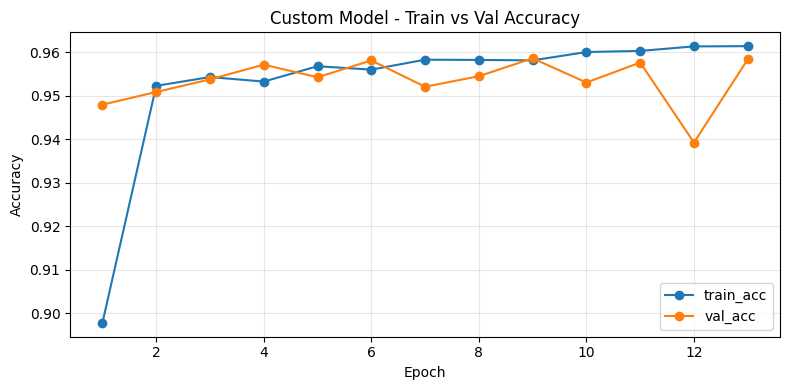

In [11]:
model_custom = CustomMalariaCNN(num_classes=len(full_ds.classes)).to(device)
model_custom, history_custom = train_model(
    model_custom,
    train_dl,
    val_dl,
    epochs=15,
    lr=8e-4,
    patience=4,
    weight_decay=1e-4,
)
plot_history(history_custom, "Custom Model - Train vs Val Accuracy")
        


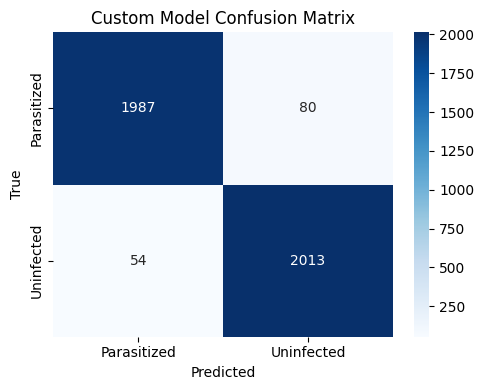

,precision,recall,f1-score,support
Parasitized,0.973542,0.961297,0.967381,2067.000000
Uninfected,0.961777,0.973875,0.967788,2067.000000
accuracy,0.967586,0.967586,0.967586,0.967586
macro avg,0.967660,0.967586,0.967585,4134.000000
weighted avg,0.967660,0.967586,0.967585,4134.000000


In [12]:
result_custom = evaluate_model(model_custom, test_dl, full_ds.classes, title="Custom Model Confusion Matrix")
display(result_custom["report_df"])
        


## [10] 결과 비교 표
노션 제출 표에 그대로 옮길 수 있게 정리한다.
        


In [13]:
summary_df = pd.DataFrame([
    {
        "model": "v1 baseline",
        "accuracy": round(result_v1["accuracy"], 4),
        "Parasitized recall": round(result_v1["parasitized_recall"], 4),
        "Uninfected recall": round(result_v1["uninfected_recall"], 4),
        "params": count_parameters(model_v1),
        "tuning": "3 conv blocks, Adam, lr=1e-3",
    },
    {
        "model": "custom model",
        "accuracy": round(result_custom["accuracy"], 4),
        "Parasitized recall": round(result_custom["parasitized_recall"], 4),
        "Uninfected recall": round(result_custom["uninfected_recall"], 4),
        "params": count_parameters(model_custom),
        "tuning": "Conv 4 blocks, BN, Dropout 0.35, AdaptiveAvgPool, weight_decay",
    },
])

display(summary_df)
print("best model:", summary_df.sort_values("accuracy", ascending=False).iloc[0]["model"])
        


,model,accuracy,Parasitized recall,Uninfected recall,params,tuning
0,v1 baseline,0.9579,0.9357,0.9802,4812610,"3 conv blocks, Adam, lr=1e-3"
1,custom model,0.9676,0.9613,0.9739,422530,"Conv 4 blocks, BN, Dropout 0.35, AdaptiveAvgPo..."


best model: custom model


## [11] 제출용 분석 작성
아래 문장을 실행 결과에 맞게 직접 다듬어 제출한다.

- 내가 설계한 CNN 구조 한 줄 요약:
  -  Conv 4블록, 채널 32->256, BatchNorm + Dropout 0.35, AdaptiveAvgPool 사용
- 설계 이유:
  - 말라리아 세포는 작은 내부 패턴 차이가 중요하므로 baseline보다 더 깊고 안정적인 특징 추출이 필요하다고 판단했다.
- 바꾸기 전/후 전체 정확도:
  - baseline: `summary_df` 1행 참고
  - custom: `summary_df` 2행 참고
- 바꾸기 전/후 Parasitized recall 비교:
  - baseline: `summary_df` 1행 참고
  - custom: `summary_df` 2행 참고
- 예상과 실제 결과가 달랐다면 이유 한 줄:
        


## [12] 선택 확장 아이디어
- 데이터 증강 추가
- learning rate scheduler 추가
- transfer learning (ResNet18 등)과 비교
- 오분류 샘플 시각화
        
